## Calculate the Lyapunov spectrum of ECA rule 150

As a sanity check, we below inspect the Lyapunov profile and spectrum for rule 150. We will generalise this to other ECAs and to LLNAs in the next document.

### _Tracing a single defect_
The Jacobian associated with an ECA of $N$ cells governed by rule 150 is
$$
\mathbf{J}(\vec{x}^t) = \mathbf{J} = \begin{pmatrix}
1 & 1 & 0 & \ldots & 0 & 0 & 1 \\
1 & 1 & 1 & \ldots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \ldots & 1 & 1 & 1 \\
1 & 0 & 0 & \ldots & 0 & 1 & 1
\end{pmatrix}.
$$
A single perturbation in cell $i=1$ is written as
$$
\delta\vec{x}_1 = \begin{pmatrix}
1\\
0\\
\vdots \\
0
\end{pmatrix},
$$
so the propagation of this perturbation in tangent space is
$$
\delta \vec{x}^t_1 = \mathbf{J}^t \delta\vec{x}_1.
$$
This column vector can be plotted in its entirety to show how many times each cell has been affected, in what is known as the _Lyapunov profile_. However, the _relevant_ Lyapunov exponent is simply the normalised logarithm of the maximal value of this column vector, i.e.
$$
\lambda_i = \lim_{t\rightarrow\infty}\frac{1}{t}\ln\left({\max_j\{\left(\mathbf{J}^t \delta\vec{x}_i\right)_j\}}\right).
$$
This value indicates the largest possible growth in defect due to an initial perturbation. There may be other places where the defect has an impact, but only the largest value will determine whether a system is chaotic or not.

### _Tracing all unit defects simultaneously_

One could iteratively calculate the Lyapunov exponent $\lambda_i$ for each defect $\delta\vec{x}_i$ individually, but that is algebraically identical to just appending all initial defects together in what you could call a perturbation sphere $\mathbf{Y}^0$:
$$
\mathbf{Y}^0 = \begin{pmatrix}
\delta\vec{x}_1 & \delta\vec{x}_2 & \cdots & \delta\vec{x}_N
\end{pmatrix}  = \mathbf{I}_N,
$$
the unit diagonal matrix (identity matrix). For rule 150, this again results in $\mathbf{Y}^t = \mathbf{J}^t \mathbf{Y}^0$. The set of Lyapunov exponents is than simply related to the maximum in each column of $\mathbf{Y}^t$.

### _Tracing the perturbation sphere_

We can also trace all defects at the same time, but in a slightly more sophisticated way (**how though?**) that arguably has a better geometric interpretation.

We are now interested in the _singular values_ of matrix $Y^t$, which is identical to the positive roots of the eigenvalues of the positive definite matrix $\Gamma^t = Y^t \times (Y^t)^T$. The singular values of $Y^t$ are geometrically interpreted as the lengths of the semi-axes of the ellipsoid represented by $Y^t$ (evolved from the initial unit sphere $Y^0$). The corresponding singular vectors represent the directions of this ellipsoid's axes (but we will not go into that here). So:
$$
\Gamma^t \vec{v}_i = \sigma_i^2 \vec{v}_i
$$
for $i \in \{1, \ldots, N\}$. Note again that $\sigma_i^2$ will indeed always be positive, because $\Gamma$ has been constructed to be positive definite. The final step is then to just plot the distribution of all $\{\sigma_i\}$ (typically in a histogram), quantifying how the unit sphere is being stretched. The Lyapunov exponents are then defined as
$$
\lambda_i = \lim_{t\rightarrow\infty}\frac{1}{t}\ln{\sigma_i} = \lim_{t\rightarrow\infty}\frac{1}{2t}\ln{\sigma_i^2}
$$
Note also that, if the Jacobian is symmetric (as is the case for rule 150), the singular values are identical to the absolute values of the eigenvalues of $\mathbf{J}$. The advantage of this approach is that it gives a more honest quantification of the _overall_ effect of initial perturbations. A disadvantage is that it is now generally unclear which perturbations are associated with which initial defect, i.e. one cannot distinguish between the effect of perturbing node $i$ versus node $j$. Given their homogeneity, this is not a big deal for ECAs. For NAs, however, individual nodes will differ in terms of network properties (such as degree), so it may be useful to document the relationship between perturbing one node versus the other.

This response of ChatGPT is quite insightful:

>**Geometrical Interpretation**
>The geometrical interpretation of the singular values lies in how the matrix $\mathbf{A}$ transforms vectors from one space to another:
>
>- Unit Sphere Transformation:
>
>Consider the unit sphere in $R_n$. This is the set of all vectors $\vec{x}$ such that $||\vec{x}|| = 1$. When the matrix $\mathbf{A}$ is applied to this unit sphere, it transforms it into an ellipsoid in $R_m$.
>
>- Axes of the Ellipsoid:
>
>The singular values of $\mathbf{A}$, denoted as $\{\sigma_1, \sigma_2, \ldots, \sigma_r\}$ (where $r$ is the rank of $\mathbf{A}$) represent the lengths of the semi-axes of this ellipsoid. The vectors in $\mathbf{V}$ (right singular vectors) determine the directions of the original space (domain) that get mapped to the principal axes of the ellipsoid in the transformed space. The vectors in $\mathbf{U}$ determine the directions in the transformed space (codomain) corresponding to the principal axes of the ellipsoid.
>
>- Stretching and Compression:
>
>Each singular value $\sigma_i$ indicates how much the matrix $\mathbf{A}$ stretches or compresses vectors along the direction of the $i$-th right singular vector.
If a singular value $\sigma_i$ is much larger than the others, it means that the matrix $\mathbf{A}$ significantly stretches vectors along the corresponding direction.
Conversely, if a singular value is much smaller (but non-zero), it indicates compression along that direction.
>Zero singular values indicate directions that are collapsed to zero, corresponding to the null space of $\mathbf{A}$

See also [this link](https://towardsdatascience.com/svd-a-geometric-view-point-cfc0c689bdc0) for another geometric explanation of the SVD.

**Question** can I find and interpret the perpendicular vectors?

We now look at the various interpretations, and apply it to a number of ECAs.

In [37]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.datasets import NetworksDataset
from src.automata import LLNA
from src.simulation import *
from src.analysis import jacobian, jacobian_ECA, calculate_Yt, lyapunov_spectrum

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# The Lyapunov profile: a single defect

In [66]:
# number of cells
N = 501

# define Jacobian for rule 150
# main diagonal
J = np.diag(np.ones(N, dtype=np.float64))
# lower and upper diagonals
J += np.diag(np.ones(N-1, dtype=np.float64), k=1)
J += np.diag(np.ones(N-1, dtype=np.float64), k=-1)
J_nonperiodic = J.copy()
# corner elements
J[0, N-1] = 1
J[N-1, 0] = 1

defect_id = N//2
delta_xi = np.zeros(N, dtype=np.float64)
delta_xi[defect_id] = 1

T = N//2
ts = np.arange(1,T)
tangent_defects = []
lambdas_i = []

Jt = J.copy()
for t in ts:
    # update defect
    print(f"t={t}", end='\r')
    tangent_defect = Jt.dot(delta_xi)
    lambda_i = np.log(np.max(tangent_defect)) / t
    lambdas_i += [lambda_i]
    tangent_defects += [tangent_defect]
    Jt = J.dot(Jt)

Text(0.5, 1.0, 'Evolution of defect profile')

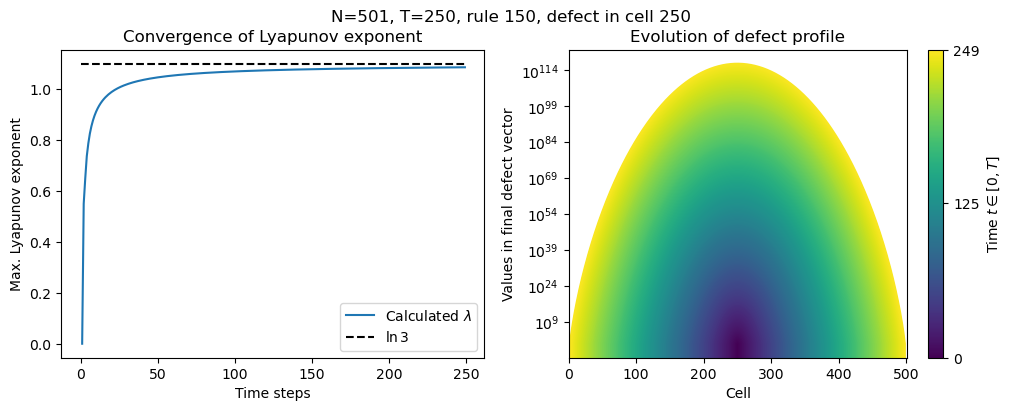

In [67]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,4))

ax1.plot(ts, lambdas_i, label=f'Calculated $\\lambda$')
ax1.plot([0, np.max(ts)], [np.log(3), np.log(3)], 'k--', label=f'$\ln{3}$')
ax1.legend()
ax1.set_ylabel("Max. Lyapunov exponent")
ax1.set_xlabel("Time steps")

# Generate a colormap
cmap = plt.get_cmap('viridis', T)

for j, td in enumerate(np.array(tangent_defects)[:-1]):
    ax2.plot(td, c=cmap(j))
    ax2.set_yscale('log')
    ax2.set_ylabel("Values in final defect vector")
    ax2.set_xlabel("Cell")
    ax2.set_xlim([0, N])

# Add color bar
norm = plt.Normalize(0, T - 1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, ticks=[0, T//2, T-1])
cbar.set_label(f'Time $t \in [0, T]$')

# add titles
fig.suptitle(f"N={N}, T={T}, rule 150, defect in cell {defect_id}")
ax1.set_title("Convergence of Lyapunov exponent")
ax2.set_title("Evolution of defect profile")

**Interpretation of the figures above**

In the figure on the lefthand side, we find the value of $\lambda_i = \lim_{t\rightarrow\infty}\frac{1}{t}\ln\left({\max_j\{\left(\mathbf{J}^t \delta\vec{x}_i\right)_j\}}\right)$, i.e. the normalised logarithm of the largest defect in tangent space after introducing a defect in node $i$. As the largest element can be shown to approach $3^t$ when $t\rightarrow\infty$, we see the asymptotic approach to the value $\ln{3}$.

In the figure on the righthand side, we observe the final state of all element in the vector $\delta\vec{x}^t$. On the $y$ axis, we find the number of defects **in tangent space** (meaning that they do not cancel out), logarithmically spaced. On the $x$ axis are the cells in our ECA. Clearly this is symmetric around cell with index $i=500$, because this is where the original defect was introduced. We show the Lyapunov profile for ever-increasing values of $T$.

# The Lyapunov profile: all defects

We can observe the same defect propagation, but now for all defects at the same time, appended in the "initial defect sphere" $Y^0$.

Text(0.5, 0, 'Cell')

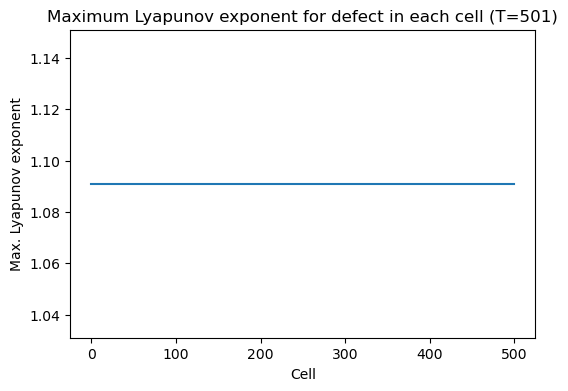

In [68]:
# number of cells
N = 501

# define Jacobian for rule 150
# main diagonal
J = np.diag(np.ones(N, dtype=np.float64))
# lower and upper diagonals
J += np.diag(np.ones(N-1, dtype=np.float64), k=1)
J += np.diag(np.ones(N-1, dtype=np.float64), k=-1)
J_nonperiodic = J.copy()
# corner elements
J[0, N-1] = 1
J[N-1, 0] = 1

# initial defect sphere
Y0 = np.diag(np.ones(N))

T = N
ts = np.arange(1,T)

Yt = Y0.copy()
for t in ts:
    print(f"t={t}", end='\r')
    # update Yt
    Yt = J.dot(Yt)
    # build in safety to avoid overflow
    if (np.isnan(Yt).any()) or not (np.isfinite(Yt).any()):
        raise Exception("Overflow!")
    
max_defects = np.max(Yt, axis=0)
max_lyapunovs = np.log(max_defects) / t

fig, ax = plt.subplots(1,1,figsize=(6,4))
ax.plot(max_lyapunovs)
ax.set_title(f"Maximum Lyapunov exponent for defect in each cell (T={T})")
ax.set_ylabel("Max. Lyapunov exponent")
ax.set_xlabel("Cell")

Clearly this is a very boring plot: the maximum Lyapunov exponent is independent of the cell in which the defect is introduced. This is expected, because all cells are equal (due to the uniformity of the ECA), and because rule 150 is additive (the Jacobian is independent of the position in phase space).

# The Lyapunov spectrum

In the third interpretation, we consider the (simultaneous) evolution of all possible single-cell defects by tracing the singular values of $Y^t$, or (equivalently) the eigenvalues of the positive definite matrix $\Gamma^t = Y^t(Y^t)^T$. We will calculate the singular values directly (avoiding additional numerical errors and making use of the efficient backbone of `numpy`)

In [73]:
# number of cells
N = 501

# define Jacobian for rule 150
# main diagonal
J = np.diag(np.ones(N, dtype=np.float64))
# lower and upper diagonals
J += np.diag(np.ones(N-1, dtype=np.float64), k=1)
J += np.diag(np.ones(N-1, dtype=np.float64), k=-1)
J_nonperiodic = J.copy()
# corner elements
J[0, N-1] = 1
J[N-1, 0] = 1

# initial defect sphere
Y0 = np.diag(np.ones(N))

# time limits
T = N
ts = np.arange(1,T)

# 
lambdas_i = []
T_interval = 10

Yt = Y0.copy()
for t in ts:
    print(f"t={t}", end='\r')
    # update defect sphere
    Yt = J.dot(Yt)
    if (np.isnan(Yt).any()) or not (np.isfinite(Yt).any()):
        raise Exception("Overflow!")
    if t%T_interval==0:
        lambdas_i_current = np.log(np.linalg.svd(Yt, compute_uv=False))/t
        lambdas_i.append(lambdas_i_current)

Text(0.5, 0.98, '$N=501$, $T=501$')

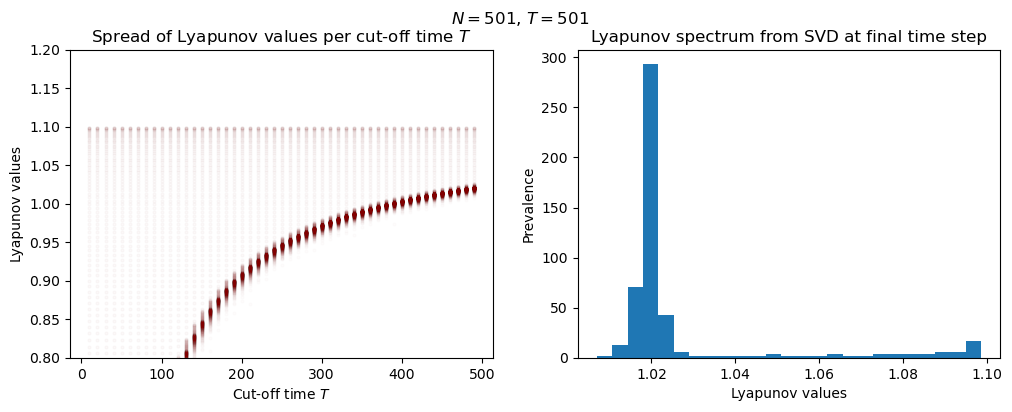

In [75]:
fig, axs = plt.subplots(1,2,figsize=(12,4))

axs[1].hist(lambdas_i[-2], bins=25)
axs[1].set_ylabel("Prevalence")
axs[1].set_xlabel("Lyapunov values")
axs[1].set_title("Lyapunov spectrum from SVD at final time step")

for j, lambdas_i_current in enumerate(lambdas_i[:-1]):
    x_values = np.ones(len(lambdas_i_current))*(j+1)*T_interval
    axs[0].scatter(x_values, lambdas_i_current, alpha=.01, s=5, color='maroon')
axs[0].set_title(f"Spread of Lyapunov values per cut-off time $T$")
axs[0].set_ylabel("Lyapunov values")
axs[0].set_xlabel(f"Cut-off time $T$")
axs[0].set_ylim([.8, 1.2])

fig.suptitle(f"$N={N}$, $T={T}$")

All Lyapunov exponents are positive, hence this system is considered to be highly chaotic and sensitive to initial conditions (as expected). What is unexpected, however, is that it is not identical to the distribution we have seen reported in Milan's paper! Let's try to reproduce this

In [77]:
# number of cells
N = 501

# define Jacobian for rule 150
# main diagonal
J = np.diag(np.ones(N, dtype=np.float64))
# lower and upper diagonals
J += np.diag(np.ones(N-1, dtype=np.float64), k=1)
J += np.diag(np.ones(N-1, dtype=np.float64), k=-1)
J_nonperiodic = J.copy()
# corner elements
J[0, N-1] = 1
J[N-1, 0] = 1

# initial defect sphere
Y0 = np.diag(np.ones(N))

# time limits
T = N//2
ts = np.arange(1,T)

Yt = Y0.copy()
Gammat = Yt.dot(Yt.T)
for t in ts:
    print(f"t={t}", end='\r')
    # update defect sphere
    Yt = J.dot(Yt)
    Gammat = Yt.dot(Yt.T)
    # make sure this is symmetric
    Gammat = (Gammat + Gammat.T)/2
    if (np.isnan(Yt).any()) or not (np.isfinite(Yt).any()):
        raise Exception("Overflow!")

lambdas_milan = np.log(np.linalg.eigvals(Gammat))/(2*T)

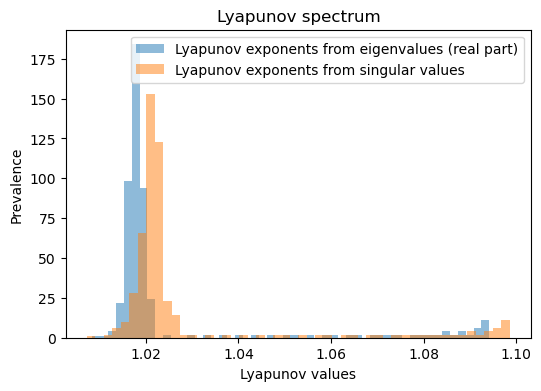

In [79]:
fig, ax = plt.subplots(1,1,figsize=(6,4))

ax.hist(np.real(lambdas_milan), bins=50, label='Lyapunov exponents from eigenvalues (real part)', alpha=.5)
ax.hist(lambdas_i[-1], bins=50, label='Lyapunov exponents from singular values', alpha=.5)
ax.set_ylabel("Prevalence")
ax.set_xlabel("Lyapunov values")
ax.set_title("Lyapunov spectrum")
ax.legend()

Clearly this does not correspond, but I suspect that is (in part) because of the numerical errors that arise. This is seen in e.g. the imaginary part of the Lyapunov values, which arise from the negative eigenvalues of $\Gamma^t$, which cannot be factual, because $\Gamma^t$ is constructed to be positive definite.

However, another observation is that the distribution appears to depend on $T$!

Note that, if this is indeed an error, the previous result is still useful, as clearly the _maximal_ value in the spectrum does correspond.

## Next

In the next step, we will generalise this approach for other ECAs, and to LLNAs.

In [ ]:
# number of cells
N = 1001
states = np.random.randint(2, size=N)

# time limits
T = N//8
ts = np.arange(1,T)

Yt = Y0.copy()
for t in ts:
    print(f"t={t}", end='\r')
    # update defect sphere
    Yt = J.dot(Yt)
    if (np.isnan(Yt).any()) or not (np.isfinite(Yt).any()):
        raise Exception("Overflow!")

lambdas_i = np.log(np.linalg.svd(Yt, compute_uv=False))/T